In [1]:
import cv2 as cv 
import numpy as np
import matplotlib.pyplot as plt

#### 1)  Write a program to read and display a grayscale image.
#### Display its histogram. What do the X and Y axes represent? 
#### Observe the histogram of various images at your disposal: pout.tif, cameraman.tif, bureau.gif, rice.tif, tire.tif, circuit.tif, ic.tif,

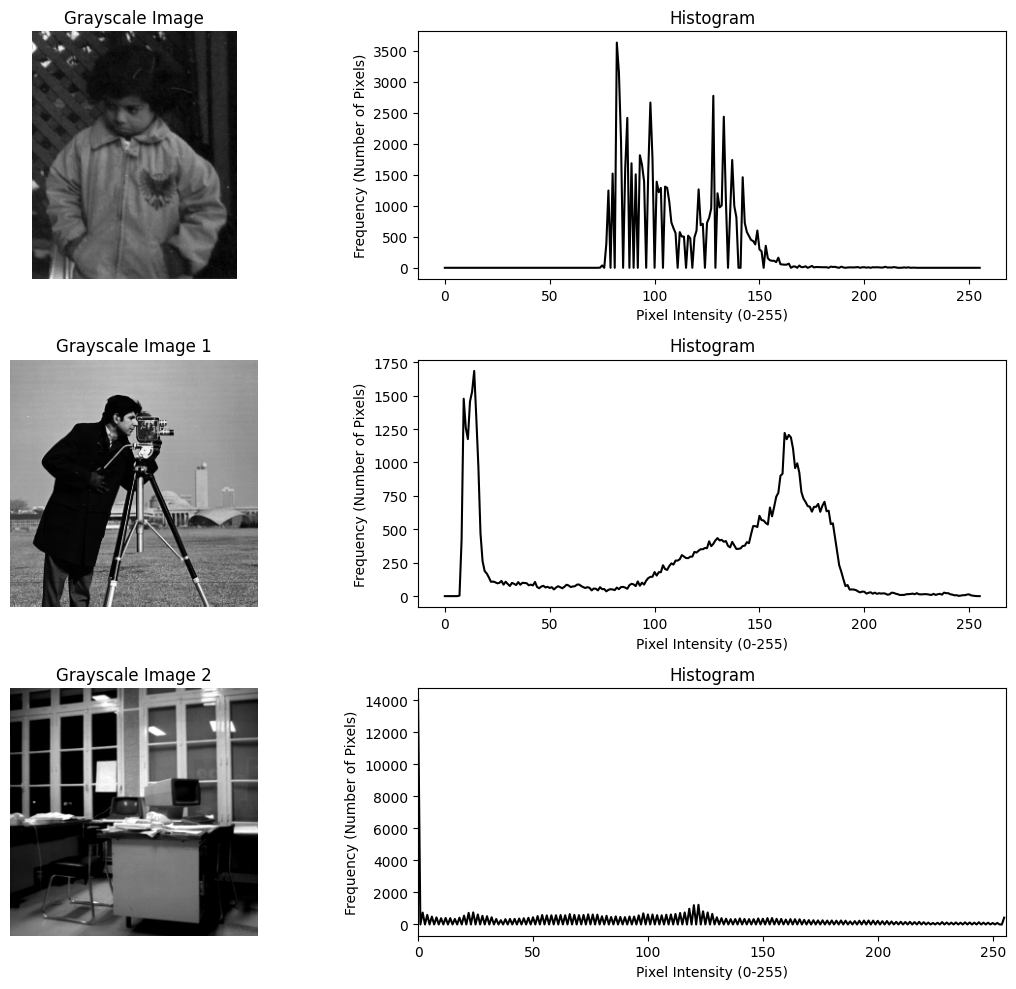

Min intensity image 1: 74, Max intensity: 224
Mean intensity: 110.30
Min intensity image 2: 7, Max intensity: 253
Mean intensity: 118.72
Min intensity image 3: 0, Max intensity: 255
Mean intensity: 80.45


In [ ]:
# Read a grayscale image
img = cv.imread('images/pout.tif', cv.IMREAD_GRAYSCALE)
img1 = cv.imread('images/cameraman.tif', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('images/bureau.gif', cv.IMREAD_GRAYSCALE)

# Display the image
plt.figure(figsize=(12, 10)) #figu
plt.subplot(3, 2, 1) # 
plt.imshow(img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(img1, cmap='gray')
plt.title('Grayscale Image 1')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(img2, cmap='gray')
plt.title('Grayscale Image 2')
plt.axis('off')

# Calculate and display histogram
histogram = cv.calcHist([img], [0], None, [256], [0, 256])
histogram1 = cv.calcHist([img1], [0], None, [256], [0, 256])
histogram2 = cv.calcHist([img2], [0], None, [256], [0, 256])

plt.subplot(3, 2, 2)
plt.plot(histogram, color='black')
plt.title('Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency (Number of Pixels)')

plt.subplot(3, 2, 4)
plt.plot(histogram1, color='black') 
plt.title('Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency (Number of Pixels)')

plt.subplot(3, 2, 6)
plt.plot(histogram2, color='black')
plt.title('Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency (Number of Pixels)')

plt.xlim([0, 256])
plt.tight_layout()
plt.show()

# Print histogram statistics
print(f"Min intensity image 1: {img.min()}, Max intensity: {img.max()}")
print(f"Mean intensity: {img.mean():.2f}") # Print mean intensity with 2 decimal places
print(f"Min intensity image 2: {img1.min()}, Max intensity: {img1.max()}")
print(f"Mean intensity: {img1.mean():.2f}") # Print mean intensity with 2 decimal places
print(f"Min intensity image 3: {img2.min()}, Max intensity: {img2.max()}")
print(f"Mean intensity: {img2.mean():.2f}") # Print mean intensity with 2 decimal places



### Interprettation : 
X represente the Pixel Intensity (0-255) and Y the Frequency (Number of Pixels)

#### 2)
 Histogram stretch: Display the minimum and maximum grayscale of and then apply an affine 
 transformation  to  match  the  minimum  grayscale  to  0  and  the  maximum  grayscale  to  1  (or 255).
  What does this transformation produce on the contrast of the image? 

Minimum grayscale for Image 1 is: 74
Maximum grayscale for Image 1 is: 224
Minimum grayscale for Image 2 is: 7
Maximum grayscale for Image 2 is: 253
Minimum grayscale for Image 3 is: 0
Maximum grayscale for Image 3 is: 240


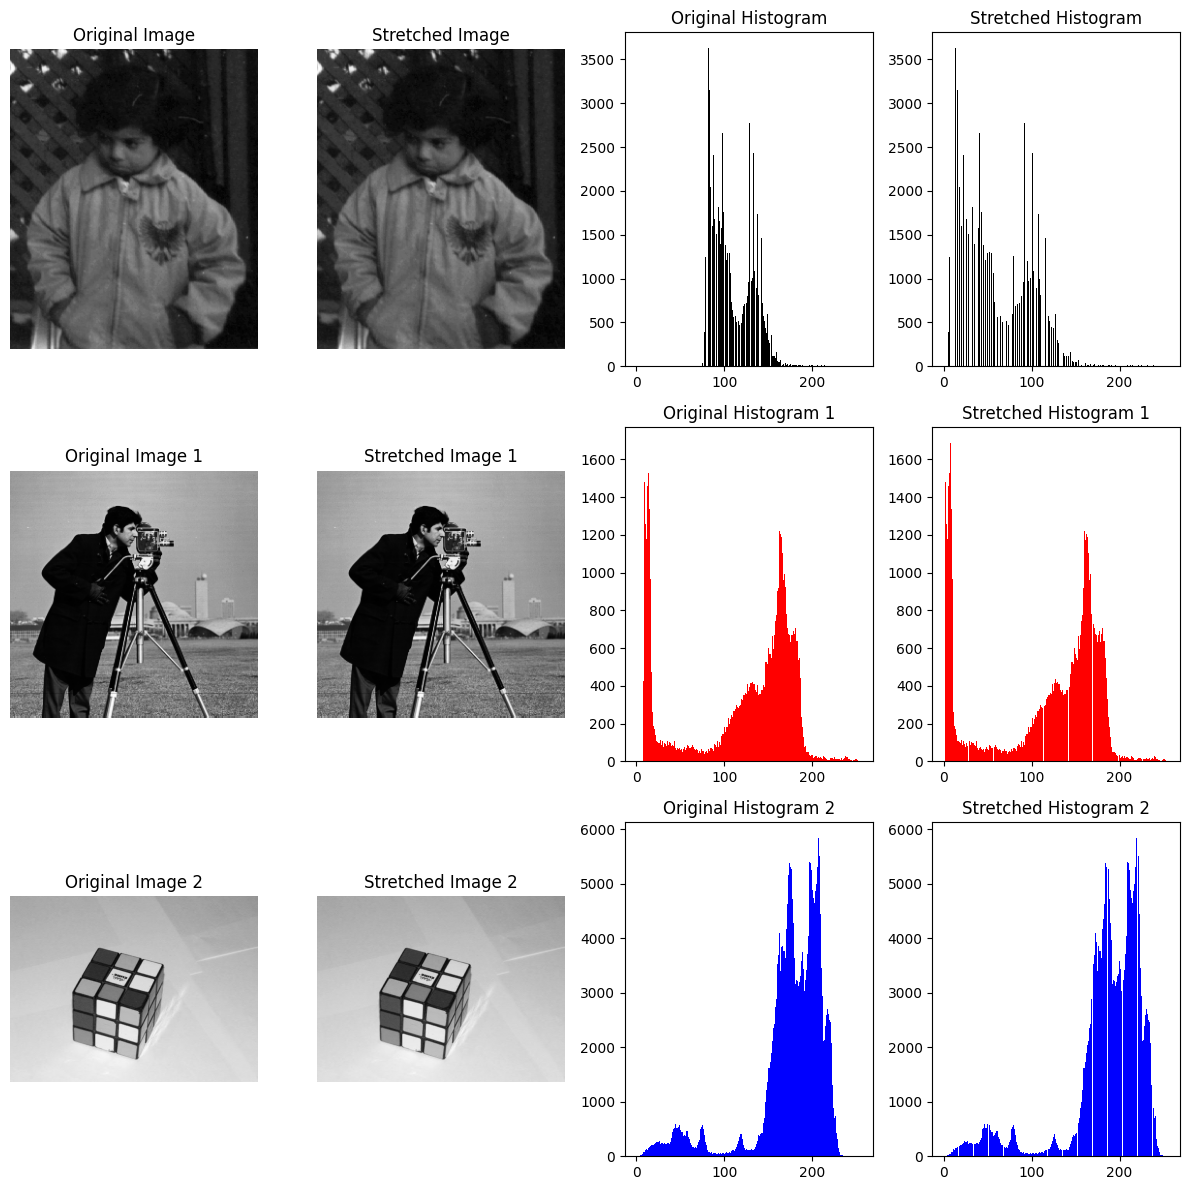

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Read images
img = cv.imread('images/pout.tif', cv.IMREAD_GRAYSCALE)
img1 = cv.imread('images/cameraman.tif', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('images/Rubiks7.JPG', cv.IMREAD_GRAYSCALE)


def histogram_stretch(image, image_name):
    min_gray = image.min()
    max_gray = image.max()

    print("Minimum grayscale for " + image_name + " is:", min_gray)
    print("Maximum grayscale for " + image_name + " is:", max_gray)

    # Avoid division by zero
    if max_gray == min_gray:
        return image.copy()

    stretched = ((image - min_gray) / (max_gray - min_gray) * 255)

    return stretched.astype(np.uint8) # Convert back to uint8 after stretching


# Apply histogram stretching
stretched_img = histogram_stretch(img, "Image 1")
stretched_img1 = histogram_stretch(img1, "Image 2")
stretched_img2 = histogram_stretch(img2, "Image 3")


# Display original and stretched images
plt.figure(figsize=(12, 12))

plt.subplot(3, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.imshow(stretched_img, cmap='gray')
plt.title('Stretched Image')
plt.axis('off')

plt.subplot(3, 4, 5)
plt.imshow(img1, cmap='gray')
plt.title('Original Image 1')
plt.axis('off')

plt.subplot(3, 4, 6)
plt.imshow(stretched_img1, cmap='gray')
plt.title('Stretched Image 1')
plt.axis('off')

plt.subplot(3, 4, 9)
plt.imshow(img2, cmap='gray')
plt.title('Original Image 2')
plt.axis('off')

plt.subplot(3, 4, 10)
plt.imshow(stretched_img2, cmap='gray')
plt.title('Stretched Image 2')
plt.axis('off')


# Histograms
plt.subplot(3, 4, 3)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Original Histogram')

plt.subplot(3, 4, 4)
plt.hist(stretched_img.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Stretched Histogram')

plt.subplot(3, 4, 7)
plt.hist(img1.ravel(), bins=256, range=[0, 256], color='red')
plt.title('Original Histogram 1')

plt.subplot(3, 4, 8)
plt.hist(stretched_img1.ravel(), bins=256, range=[0, 256], color='red')
plt.title('Stretched Histogram 1')

plt.subplot(3, 4, 11)
plt.hist(img2.ravel(), bins=256, range=[0, 256], color='blue')
plt.title('Original Histogram 2')

plt.subplot(3, 4, 12)
plt.hist(stretched_img2.ravel(), bins=256, range=[0, 256], color='blue')
plt.title('Stretched Histogram 2')


plt.tight_layout()
plt.show()


### Interpretation : 

the affine transformation's formula used  is the following 

$$
g = \frac{f - f_{\min}}{f_{\max} - f_{\min}} \times 255
$$

this transformation produce  a slit increase of the image contrast. more generally The affine transformation expands the grayscale range to [0,255], increasing the contrast of the image and making dark and bright details more distinguishable.

#### 3)
Gain/Offset Setting: Apply an affine transformation of the intensity: O = Gain * I + Offset Investigate the influence of gain and  offset adjustment on multiple images. 
#### 

How do these two parameters  act  on  the  histogram?  Which  histogram  should  be  looked  for  when  acquiring  an image to make full use of the sensor's dynamic range and achieve good contrast?

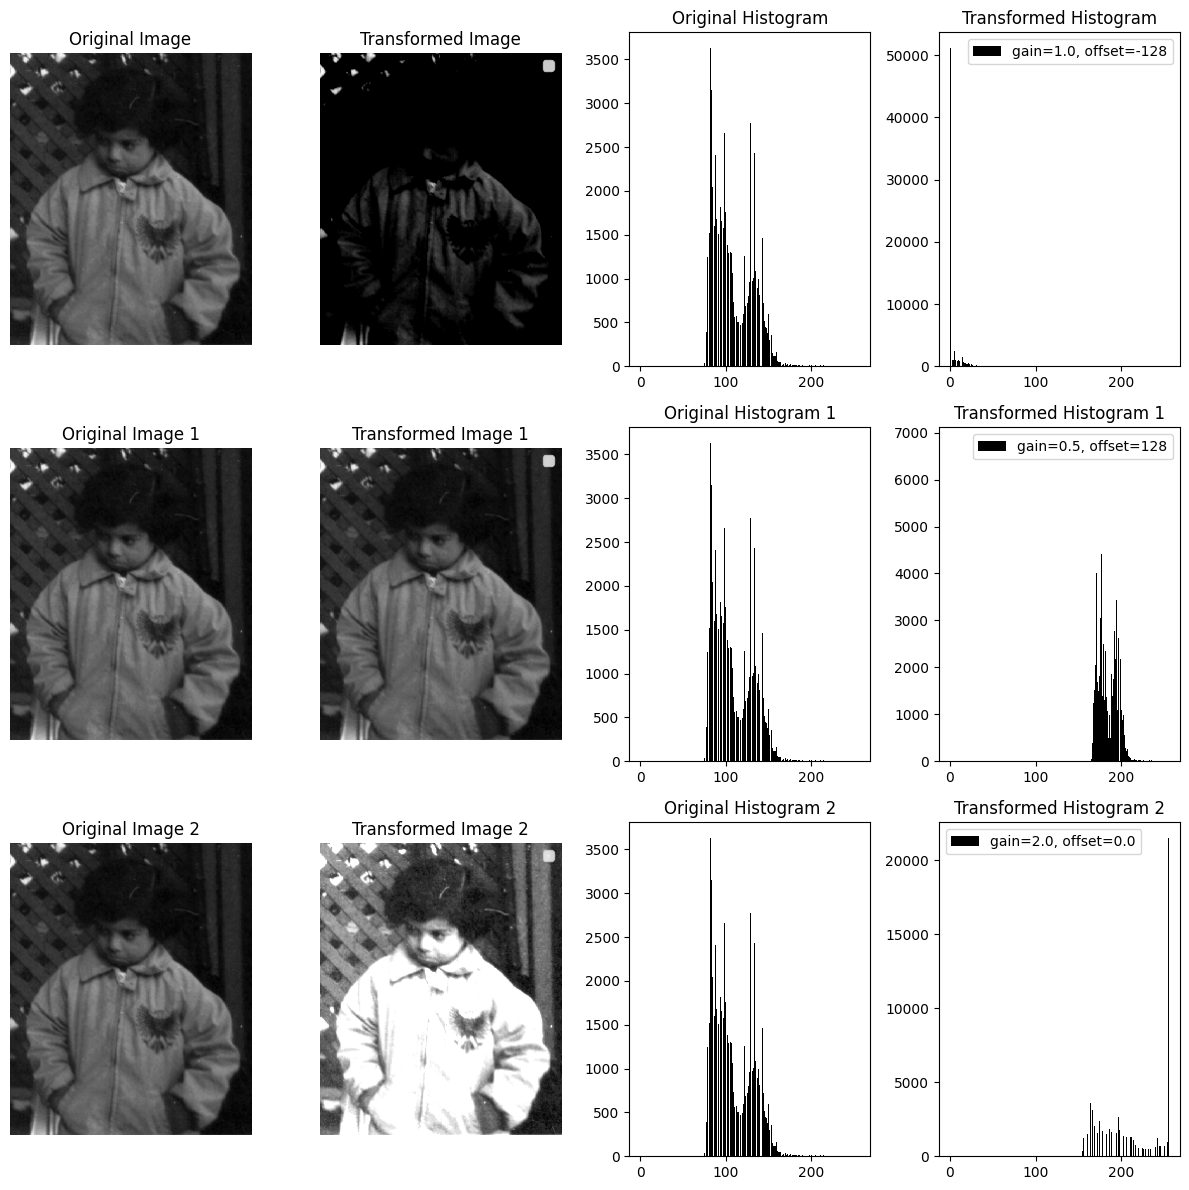

In [34]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Read images
img = cv.imread('images/pout.tif', cv.IMREAD_GRAYSCALE)
img1 = cv.imread('images/cameraman.tif', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('images/Rubiks7.JPG', cv.IMREAD_GRAYSCALE)


def  OUT(image,gain, offset): 
    image_intensity = image.astype(np.float32)  # Convert to float for calculations

    adjusted_image = gain * image_intensity + offset
    adjusted_image = np.clip(adjusted_image, 0, 255)  # Clip values to the valid range [0, 255]
    return adjusted_image.astype(np.uint8)



# Apply transformation
transformed_img =  OUT(img, gain=1.0, offset=-128)
transformed_img1 =  OUT(img, gain=0.5, offset=128)
transformed_img2 =  OUT(img, gain=2.0, offset=0.0)


# Display original and transformed images
plt.figure(figsize=(12, 12))

plt.subplot(3, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.imshow(transformed_img, cmap='gray')
plt.title("Transformed Image")
plt.legend(['gain=' + str(1.0) + ', offset=' + str(-128)])
plt.axis('off')

plt.subplot(3, 4, 5)
plt.imshow(img, cmap='gray')
plt.title('Original Image 1')
plt.axis('off')

plt.subplot(3, 4, 6)
plt.imshow(transformed_img1, cmap='gray')
plt.title('Transformed Image 1')
plt.legend(['gain=' + str(0.5) + ', offset=' + str(128)])
plt.axis('off')

plt.subplot(3, 4, 9)
plt.imshow(img, cmap='gray')
plt.title('Original Image 2')
plt.axis('off')

plt.subplot(3, 4, 10)
plt.imshow(transformed_img2, cmap='gray')
plt.title("Transformed Image 2")
plt.legend(['gain=' + str(2.0) + ', offset=' + str(0.0)])
plt.axis('off')


# Histograms
plt.subplot(3, 4, 3)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Original Histogram')

plt.subplot(3, 4, 4)
plt.hist(transformed_img.ravel(), bins=256, range=[0, 256], color='black')
plt.title("Transformed Histogram")
plt.legend(['gain=' + str(1.0) + ', offset=' + str(-128)])

plt.subplot(3, 4, 7)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='black')
plt.title("Original Histogram 1")

plt.subplot(3, 4, 8)
plt.hist(transformed_img1.ravel(), bins=256, range=[0, 256], color='black')
plt.title("Transformed Histogram 1")
plt.legend(['gain=' + str(0.5) + ', offset=' + str(128)])

plt.subplot(3, 4, 11)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Original Histogram 2')

plt.subplot(3, 4, 12)
plt.hist(transformed_img2.ravel(), bins=256, range=[0, 256], color='black')
plt.title("Transformed Histogram 2")
plt.legend(['gain=' + str(2.0) + ', offset=' + str(0.0)])

plt.tight_layout()
plt.show()


### Interpretattion :  
$$
O = Gain \times I + Offset
$$

Le gain contrôle le contraste de l'image. Augmenter le gain étend
l'histogramme horizontalement et augmente le contraste, Diminuant le gain comprime l'histogramme et réduit le contraste.

L'offset décale l'histogramme horizontalement. Un offset positif déplace le
histogramme vers des intensités plus élevées, rendant l'image plus lumineuse, tandis qu'un
un offset négatif le déplace vers des intensités plus faibles, rendant l'image plus sombre.

Pour exploiter pleinement la plage dynamique du capteur et obtenir un bon contraste,
l'image acquise devrait idéalement avoir un histogramme qui couvre la plupart des
plage d'intensité disponible, de 0 à 255, tout en évitant les
écrêtage à 0 et 255.


##### Paramètre	Effet sur l'histogramme	et sur l'image
Gain > 1	
###### Étirement horizontal l'histogramme  augmente le Contraste de l'image 
0 < Gain < 1	
###### Compression horizontale l'histogramme   et diminue  le Contraste de l'image
Offset > 0	
###### Déplacement vers la droite de l'histogramme Image plus claire
Offset < 0	
###### Déplacement vers la gauche de l'histogramme	Image plus sombre

#### 4) Gamma correction: corresponds to a non-linear transformation of the intensity
 
#### What brightness correction causes a value γ<1 ? a value  γ>1? Correct an underexposed image. 

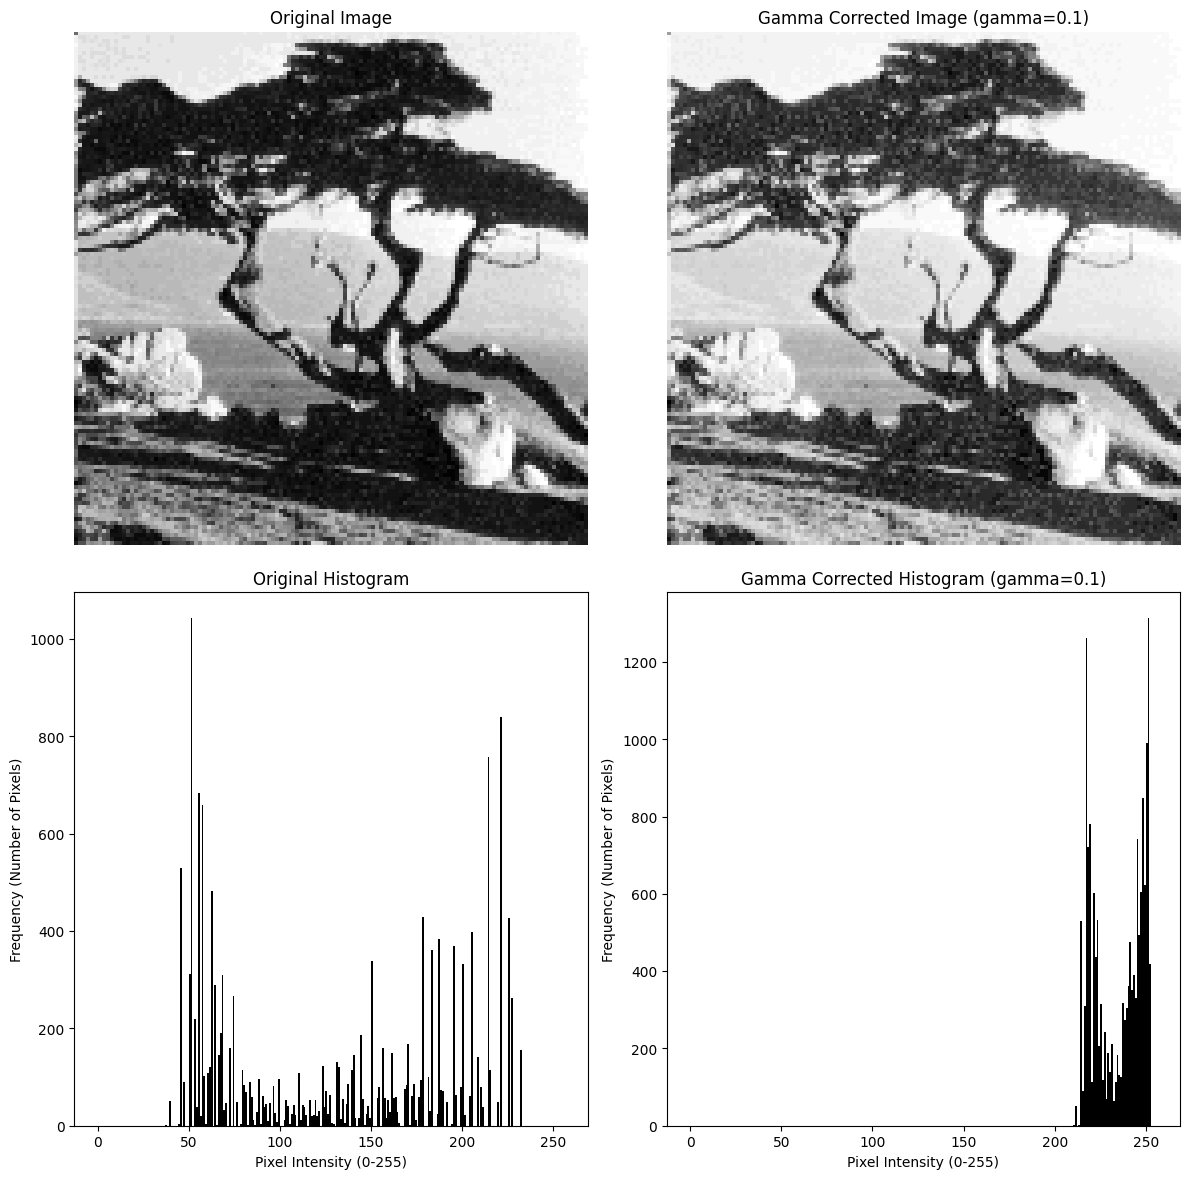

In [ ]:
image = cv.imread('images/tree.gif', cv.IMREAD_GRAYSCALE)

def gamma_correction(img_original, gamma):
    lookUpTable = np.empty((1,256), np.uint8)
    for i in range(256):
        lookUpTable[0,i] = np.clip(pow(i / 255.0, gamma) * 255.0, 0, 255) # 
    res = cv.LUT(img_original, lookUpTable)
    return res

gamma_value = 0.10  
img_corrected = gamma_correction(image, gamma_value)


plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_corrected, cmap='gray')
plt.title(f'Gamma Corrected Image (gamma={gamma_value})')
plt.axis('off')


plt.subplot(2, 2, 4)
plt.hist(img_corrected.ravel(), bins=256, range=[0, 256], color='black')
plt.title(f'Gamma Corrected Histogram (gamma={gamma_value})')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency (Number of Pixels)')

plt.subplot(2, 2, 3)
plt.hist(image.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Original Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency (Number of Pixels)')

plt.tight_layout()
plt.show()  

### Interpretattion 
 γ<1 = éclaircit l’image

 γ>1 = assombrit l’image
 
 Pour corriger une image sous-exposée, on prend γ<1 (par exemple 0.45 ou 0.5)

#### 5) 
Histogram equalization: this transformation is calculated to distribute the intensities as well as possible,  using  the  entire  range  uniformly  (i.e.  to  approach  a  flat  histogram).
 
#### 
Apply  histogram equalization to different images under different light conditions and observe the results.

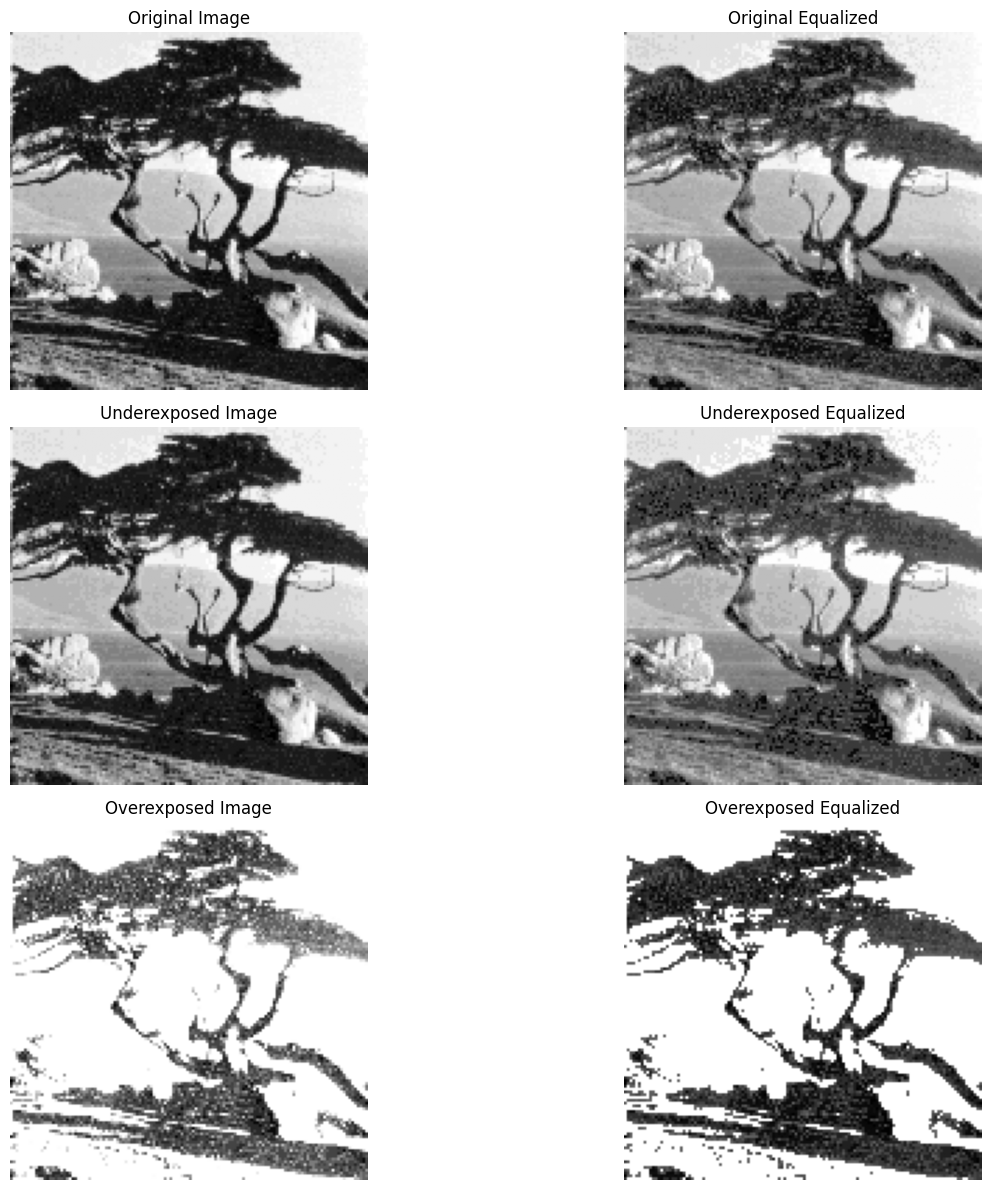

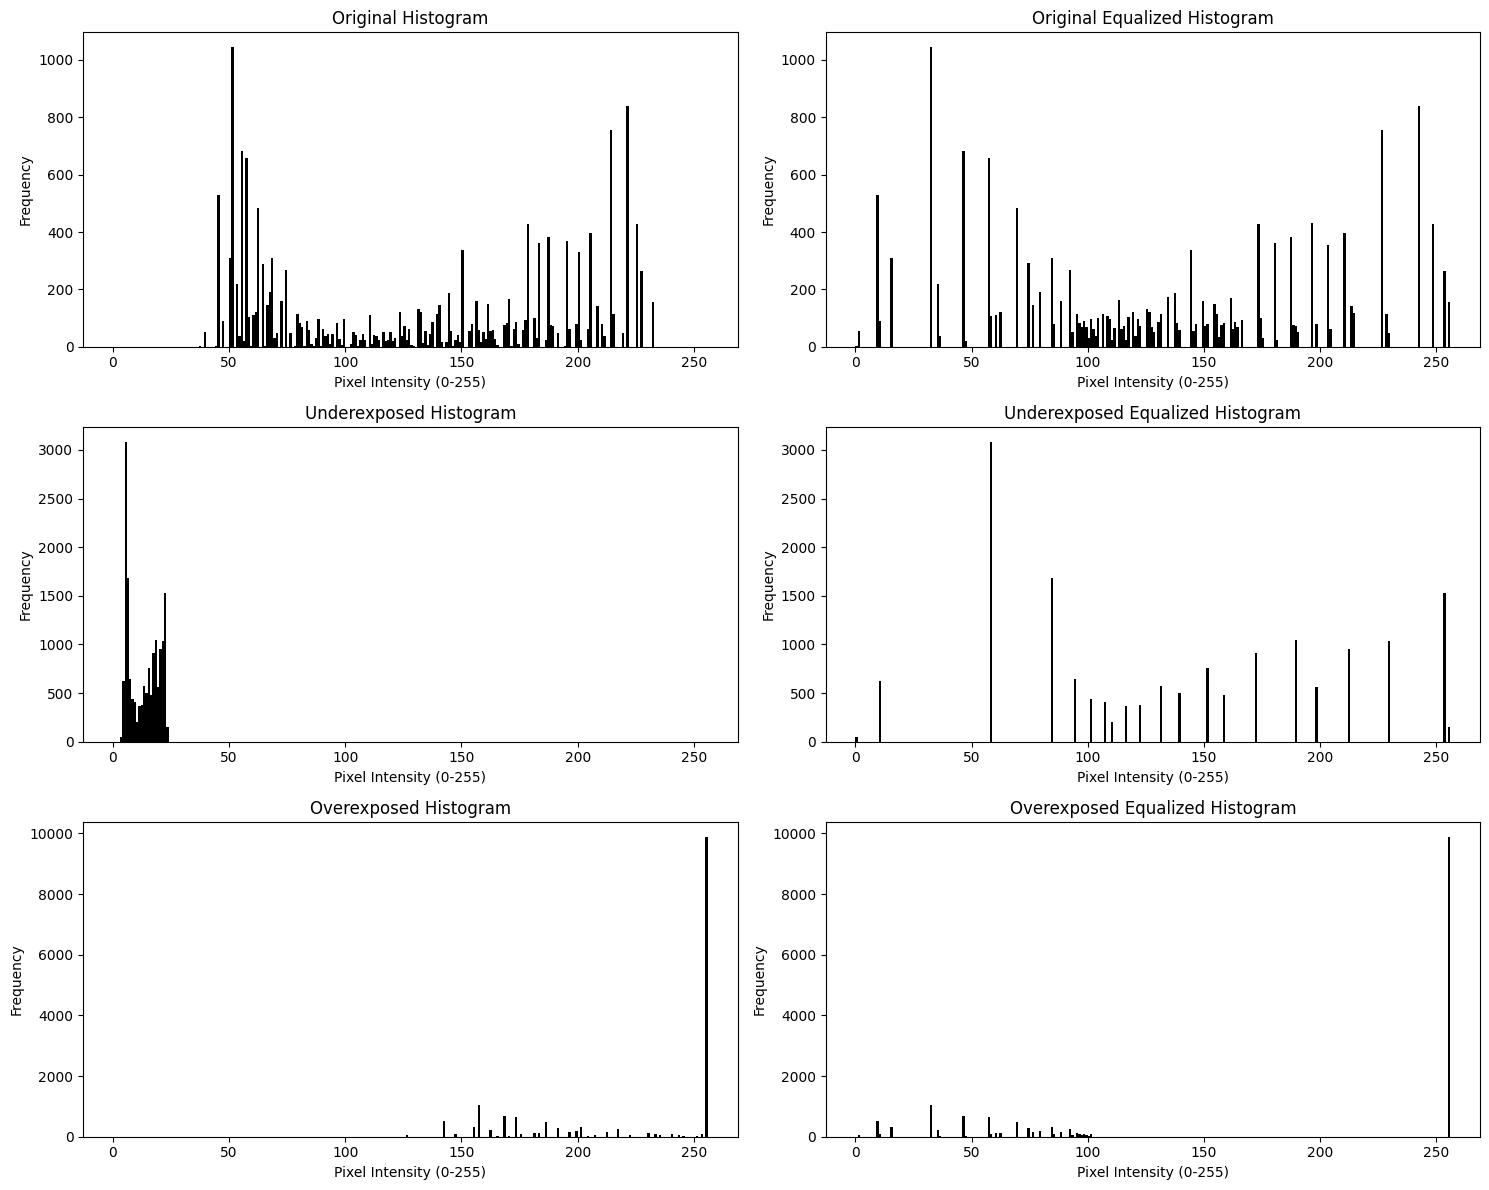

In [70]:


# Histogram equalization on images under different illumination conditions
img3 = cv.imread('images/tree.gif', cv.IMREAD_GRAYSCALE)
images = {
    "Original": img3,
    "Underexposed": np.clip(img3.astype(np.float32) * 0.1, 0, 255).astype(np.uint8), # Underexposed image 0.5 rrepresents the factor by which the pixel values are multiplied to darken the image 
    "Overexposed": np.clip(img3.astype(np.float32) * 2.6 + 25, 0, 255).astype(np.uint8), # Overexposed image 1.6 represents the factor by which the pixel values are multiplied to brighten the image, and 25 is added to further increase brightness
}

plt.figure(figsize=(15, 12))

for i, (name, image) in enumerate(images.items(), start=1):
    equalized = cv.equalizeHist(image)

    plt.subplot(3, 2, 2*i - 1)
    plt.imshow(image, cmap='gray')
    plt.title(name + ' Image')
    plt.axis('off')

    plt.subplot(3, 2, 2*i)
    plt.imshow(equalized, cmap='gray')
    plt.title(name + ' Equalized')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Histograms before and after equalization
plt.figure(figsize=(15, 12))

for i, (name, image) in enumerate(images.items(), start=1):
    equalized = cv.equalizeHist(image)

    plt.subplot(3, 2, 2*i - 1)
    plt.hist(image.ravel(), bins=256, range=[0, 256], color='black')
    plt.title(name + ' Histogram')
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Frequency')

    plt.subplot(3, 2, 2*i)
    plt.hist(equalized.ravel(), bins=256, range=[0, 256], color='black')
    plt.title(name + ' Equalized Histogram')
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


#### Interpretation: 

Une image sous-exposée a beaucoup de pixels dans les zones sombres. L’égalisation étale ces intensités sur toute la plage [0,255].

Une image sur-exposée a beaucoup de pixels dans les zones claires. L’égalisation la rend aussi plus lisible.

L’égalisation améliore le contraste, elle permet une meilleur repartition du niveau de gris 